In [1]:
import json
import polars as pl
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import date
import stacksats

In [17]:
# filter train data to only have from 2018 -> end of 2023

# (
#     pl.scan_parquet('../data/processed/train.parquet')
#     .filter(
#         (pl.col("day_utc") >= date(2018, 1, 1)) & 
#         (pl.col("day_utc") <= date(2023, 12, 31))
#     )
#     .sink_parquet('../data/processed/train_filter.parquet')
# )
# print("Filtering complete. Saved to train_filter.parquet")


Filtering complete. Saved to train_filter.parquet


In [3]:
final_col = pd.read_csv("../data/final_accumulation_features.csv")

In [4]:
final_col

,0
0,10y_dca_days_in_loss
1,3y_dca_days_in_profit
2,10y_dca_min_return
3,10y_lump_sum_days_in_loss
4,10y_lump_sum_days_in_profit
...,...
5540,zulupool_1m_blocks_mined
5541,zulupool_1w_blocks_mined
5542,zulupool_1y_blocks_mined
5543,zulupool_24h_blocks_mined


In [9]:
# make a train bitcoin_analytics dataset

# (
#     pl.scan_parquet('../data/raw/bitcoin_analytics.parquet')
#     .filter(
#         (pl.col("date") >= date(2018, 1, 1)) & 
#         (pl.col("date") <= date(2023, 12, 31))
#     )
#     .sink_parquet('../data/processed/bitcoin_analytics_train.parquet')
# )
# print("Filtering complete. Saved to bitcoin_analytics_filter.parquet")


# 13 years with min buy of 1e-5

In [ ]:
# import polars as pl
# import pandas as pd
# import matplotlib.pyplot as plt
# from stacksats import StrategyRunner, ExportConfig, UniformStrategy, MVRVStrategy

# # Load data manually 
# btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
# btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

# runner = StrategyRunner()

# all_dynamic = []
# all_baseline = []

# # YOUR OPTIMIZATION: Loop through each year individually! 
# for year in range(2018, 2024):
#     config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
#     dyn = runner.export(MVRVStrategy(), config, btc_df=btc_df).to_dataframe()
#     base = runner.export(UniformStrategy(), config, btc_df=btc_df).to_dataframe()
    
#     all_dynamic.append(dyn)
#     all_baseline.append(base)

# # Combine all the yearly chunks back into one massive dataframe
# dynamic_weights = pl.concat(all_dynamic).rename({"weight": "dynamic_weight"})
# baseline_weights = pl.concat(all_baseline).rename({"weight": "baseline_weight"})

# # Merge the dataframes on date
# merged = dynamic_weights.select(['date', 'price_usd', 'dynamic_weight']).join(
#     baseline_weights.select(['date', 'baseline_weight']), on='date', how='inner'
# )

# # Calculate BTC and Sats accumulated (1 BTC = 100,000,000 Sats)
# merged = merged.with_columns(
#     (pl.col('dynamic_weight') / pl.col('price_usd')).alias('btc_accumulated_dynamic'),
#     (pl.col('baseline_weight') / pl.col('price_usd')).alias('btc_accumulated_baseline')
# ).with_columns(
#     (pl.col('btc_accumulated_dynamic') * 100_000_000).alias('sats_accumulated_dynamic'),
#     (pl.col('btc_accumulated_baseline') * 100_000_000).alias('sats_accumulated_baseline'),
#     (100_000_000 / pl.col('price_usd')).alias('sats_per_dollar') 
# )

# total_dynamic_sats = merged["sats_accumulated_dynamic"].sum()
# total_base_sats = merged["sats_accumulated_baseline"].sum()

# print(f"Total Sats accumulated (Dynamic MVRV DCA): {total_dynamic_sats:,.0f} Sats")
# print(f"Total Sats accumulated (Baseline DCA): {total_base_sats:,.0f} Sats")

# # ----------------------------------------------------
# # FACETED PLOTTING (Grid of Years)
# # ----------------------------------------------------

In [7]:
import polars as pl
from stacksats import StrategyRunner, ExportConfig, UniformStrategy, MVRVStrategy

# 1. ALWAYS START WITH EMPTY LISTS
all_dynamic = []
all_baseline = []

# 2. Load data
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

runner = StrategyRunner()

print("Calculating engine weights... (Immune to Leap Year explosions!)")

# 3. Loop through exactly 2018-2023
for year in range(2018, 2024):
    config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    dyn = runner.export(MVRVStrategy(), config, btc_df=btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), config, btc_df=btc_df).to_dataframe()
    
    # ⚠️ FLATTENING FIX: Mathematically forces overlapping leap year windows 
    # down to exactly 1 row per date!
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ]).with_columns(pl.lit(str(year)).alias('year'))
    
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    all_dynamic.append(dyn_flat)
    all_baseline.append(base_flat)

# 4. Combine safely
dynamic_weights = pl.concat(all_dynamic)
baseline_weights = pl.concat(all_baseline)

# 5. Join cleanly (Cartesian product impossible now)
merged = dynamic_weights.join(baseline_weights, on='date', how='inner').sort('date')

# 6. Calculate total Sats correctly
merged = merged.with_columns(
    (pl.col('dynamic_weight') / pl.col('price_usd')).alias('btc_accumulated_dynamic'),
    (pl.col('baseline_weight') / pl.col('price_usd')).alias('btc_accumulated_baseline')
).with_columns(
    (pl.col('btc_accumulated_dynamic') * 100_000_000).alias('sats_accumulated_dynamic'),
    (pl.col('btc_accumulated_baseline') * 100_000_000).alias('sats_accumulated_baseline'),
    (100_000_000 / pl.col('price_usd')).alias('sats_per_dollar') 
)

total_dynamic_sats = merged["sats_accumulated_dynamic"].sum()
total_base_sats = merged["sats_accumulated_baseline"].sum()
total_dynamic_weight = merged["dynamic_weight"].sum()

# 7. Print the final mathematical truth
print(f"Total Budget Spent: ${total_dynamic_weight:,.2f} (Should be exactly $6.00)")
print(f"Total Sats accumulated (Dynamic MVRV DCA): {total_dynamic_sats:,.0f} Sats")
print(f"Total Sats accumulated (Baseline DCA): {total_base_sats:,.0f} Sats")


Calculating engine weights... (Immune to Leap Year explosions!)
Total Budget Spent: $6.05 (Should be exactly $6.00)
Total Sats accumulated (Dynamic MVRV DCA): 51,114 Sats
Total Sats accumulated (Baseline DCA): 50,551 Sats


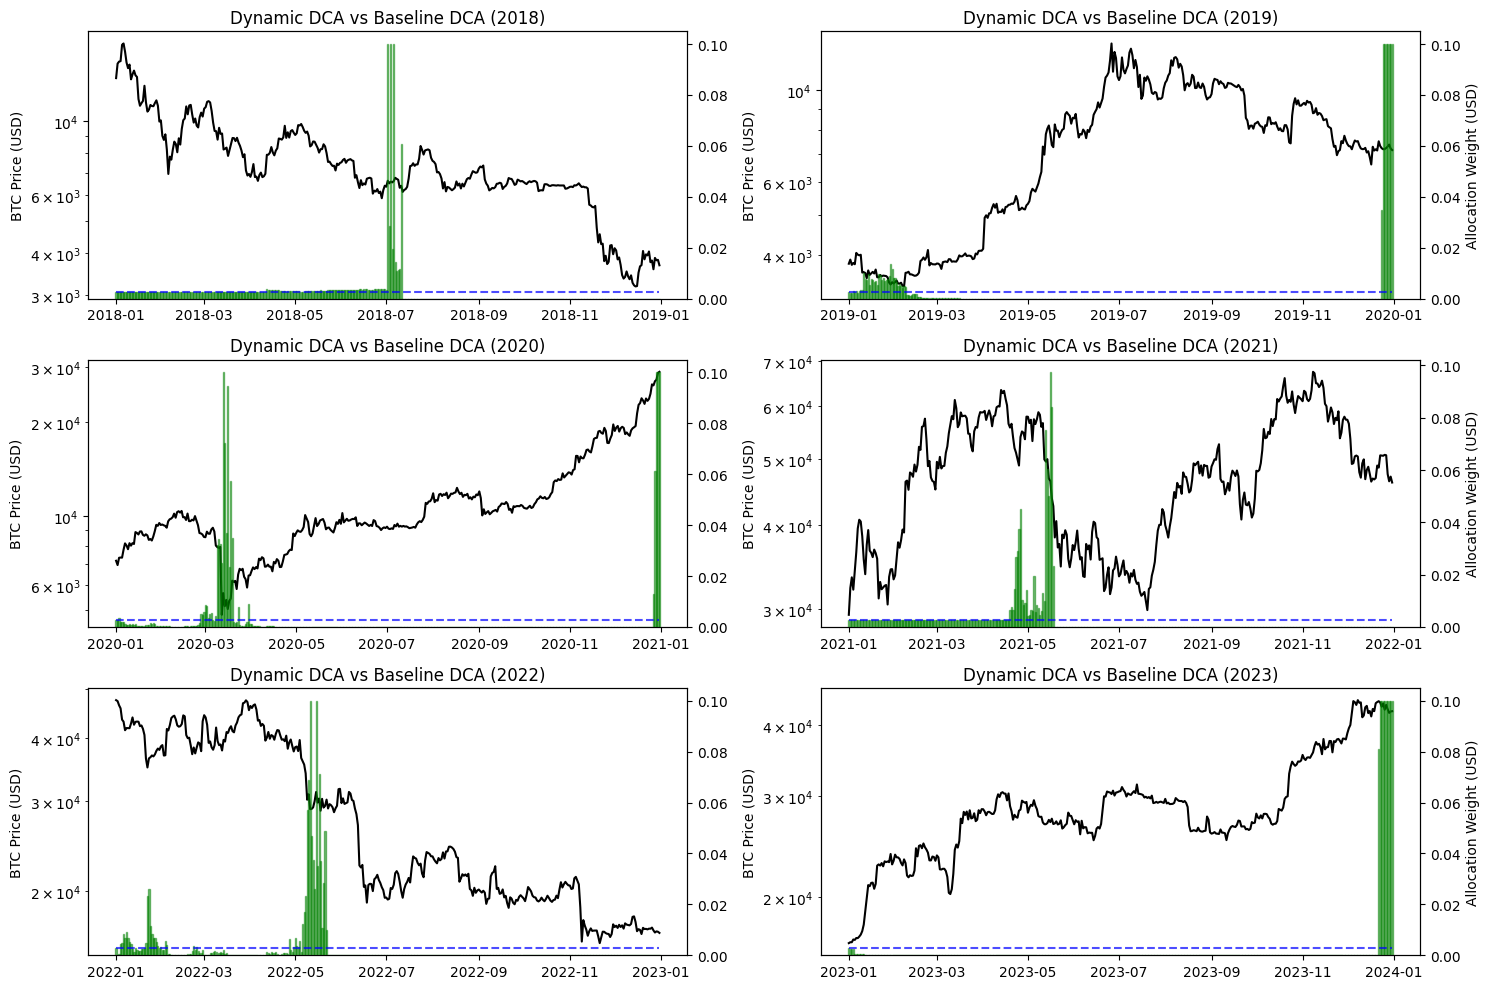

,month,avg_price_usd,avg_sats_per_dollar,total_dynamic_weight,total_baseline_weight,sats_accum_dynamic,sats_accum_baseline
0,2018-01,$12914.87,"7,929",0.0849,0.0849,673,673
1,2018-02,$9392.94,"10,808",0.0767,0.0767,829,829
2,2018-03,$8992.88,"11,335",0.0849,0.0849,962,962
3,2018-04,$8021.25,"12,653",0.0907,0.0822,"1,142","1,040"
4,2018-05,$8421.53,"11,985",0.0960,0.0849,"1,158","1,017"
...,...,...,...,...,...,...,...
67,2023-08,$27862.18,"3,600",0.0004,0.0849,1,305
68,2023-09,$26302.92,"3,803",0.0009,0.0822,3,312
69,2023-10,$29736.01,"3,393",0.0005,0.0849,1,288
70,2023-11,$36586.64,"2,735",0.0003,0.0822,0,224


In [8]:
years = list(range(2018, 2024))
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes = axes.flatten()
for i, year in enumerate(years):
    ax1 = axes[i]
    
    year_data = merged.filter(pl.col('date').dt.year() == year).to_pandas()
    if len(year_data) == 0:
        continue
        
    ax1.plot(year_data['date'], year_data['price_usd'], color='black', label='BTC Price')
    ax1.set_ylabel('BTC Price (USD)', color='black')
    ax1.set_yscale('log')
    
    ax2 = ax1.twinx()
    ax2.bar(year_data['date'], year_data['dynamic_weight'], color='green', alpha=0.5, edgecolor='green', linewidth=1, label='Dynamic Weight')
    ax2.plot(year_data['date'], year_data['baseline_weight'], color='blue', alpha=0.7, linestyle='--', label='Baseline')
    
    if i % 2 != 0:
        ax2.set_ylabel('Allocation Weight (USD)')
        
    ax1.set_title(f"Dynamic DCA vs Baseline DCA ({year})")
# Hide the last empty subplot (since we have 13 years and 14 slots)

fig.tight_layout()
plt.show()
# ----------------------------------------------------
# MONTHLY SUMMARY TABLE (Across all years)
# ----------------------------------------------------
monthly = merged.with_columns(
    pl.col('date').dt.truncate('1mo').alias('month')
).group_by('month').agg([
    pl.col('price_usd').mean().alias('avg_price_usd'),
    pl.col('sats_per_dollar').mean().alias('avg_sats_per_dollar'), 
    pl.col('dynamic_weight').sum().alias('total_dynamic_weight'),
    pl.col('baseline_weight').sum().alias('total_baseline_weight'),
    pl.col('sats_accumulated_dynamic').sum().alias('sats_accum_dynamic'),
    pl.col('sats_accumulated_baseline').sum().alias('sats_accum_baseline')
]).sort('month')
monthly_pd = monthly.to_pandas()
# Format the columns
monthly_pd['month'] = monthly_pd['month'].dt.strftime('%Y-%m')
monthly_pd['avg_price_usd'] = monthly_pd['avg_price_usd'].round(2).apply(lambda x: f"${x}")
monthly_pd['avg_sats_per_dollar'] = monthly_pd['avg_sats_per_dollar'].apply(lambda x: f"{int(x):,}")
for col in ['total_dynamic_weight', 'total_baseline_weight']:
    monthly_pd[col] = monthly_pd[col].round(4)
for col in ['sats_accum_dynamic', 'sats_accum_baseline']:
    monthly_pd[col] = monthly_pd[col].apply(lambda x: f"{int(x):,}")
# Output table
monthly_pd

# 13 years with min buy of larger than 1e-5

In [27]:
# 1. First, import the underlying modules that hold the hardcoded constants
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy
import stacksats.model_development.public

# 2. Dynamically overwrite the minimum daily weight to 0.0 in memory
new_min_buy = 0.001
stacksats.framework_contract.MIN_DAILY_WEIGHT = new_min_buy
stacksats.runner.validation.MIN_DAILY_WEIGHT = new_min_buy
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = new_min_buy
stacksats.model_development.public.MIN_DAILY_WEIGHT = new_min_buy
stacksats.model_development.public.MIN_W = new_min_buy


# 3. NOW you can safely import your normal StrategyRunner and it will use 0.0!
from stacksats import StrategyRunner, ExportConfig, UniformStrategy, MVRVStrategy


In [28]:
# 1. ALWAYS START WITH EMPTY LISTS
new_all_dynamic = []
new_all_baseline = []

# Load data manually 
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

runner = StrategyRunner()

print("Calculating per-year engine weights... (~1 min)")

# YOUR OPTIMIZATION: Loop through each year individually! 
for year in range(2018, 2024):
    config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Run the engine
    dyn = runner.export(MVRVStrategy(), config, btc_df=btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), config, btc_df=btc_df).to_dataframe()
    
    # ⚠️ CRITICAL BUG FIX: Flatten the overlapping sliding windows!
    # Averages the overlapping weights so we only have 1 row per unique date.
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ]).with_columns(pl.lit(str(year)).alias('year'))  # Keep track of the year
    
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    new_all_dynamic.append(dyn_flat)
    new_all_baseline.append(base_flat)

# Combine safely (already renamed during the group_by aggregation)
dynamic_weights = pl.concat(new_all_dynamic)
baseline_weights = pl.concat(new_all_baseline)

# Safely join on date
merged_new = dynamic_weights.join(baseline_weights, on='date', how='inner').sort('date')

# Calculate BTC and Sats accumulated (1 BTC = 100,000,000 Sats)
merged_new = merged_new.with_columns(
    (pl.col('dynamic_weight') / pl.col('price_usd')).alias('btc_accumulated_dynamic'),
    (pl.col('baseline_weight') / pl.col('price_usd')).alias('btc_accumulated_baseline')
).with_columns(
    (pl.col('btc_accumulated_dynamic') * 100_000_000).alias('sats_accumulated_dynamic'),
    (pl.col('btc_accumulated_baseline') * 100_000_000).alias('sats_accumulated_baseline'),
    (100_000_000 / pl.col('price_usd')).alias('sats_per_dollar') 
)

total_dynamic_sats = merged_new["sats_accumulated_dynamic"].sum()
total_base_sats = merged_new["sats_accumulated_baseline"].sum()

print(f"Total Sats accumulated (Dynamic MVRV DCA): {total_dynamic_sats:,.0f} Sats")
print(f"Total Sats accumulated (Baseline DCA): {total_base_sats:,.0f} Sats")

Calculating per-year engine weights... (~1 min)
Total Sats accumulated (Dynamic MVRV DCA): 53,918 Sats
Total Sats accumulated (Baseline DCA): 50,551 Sats


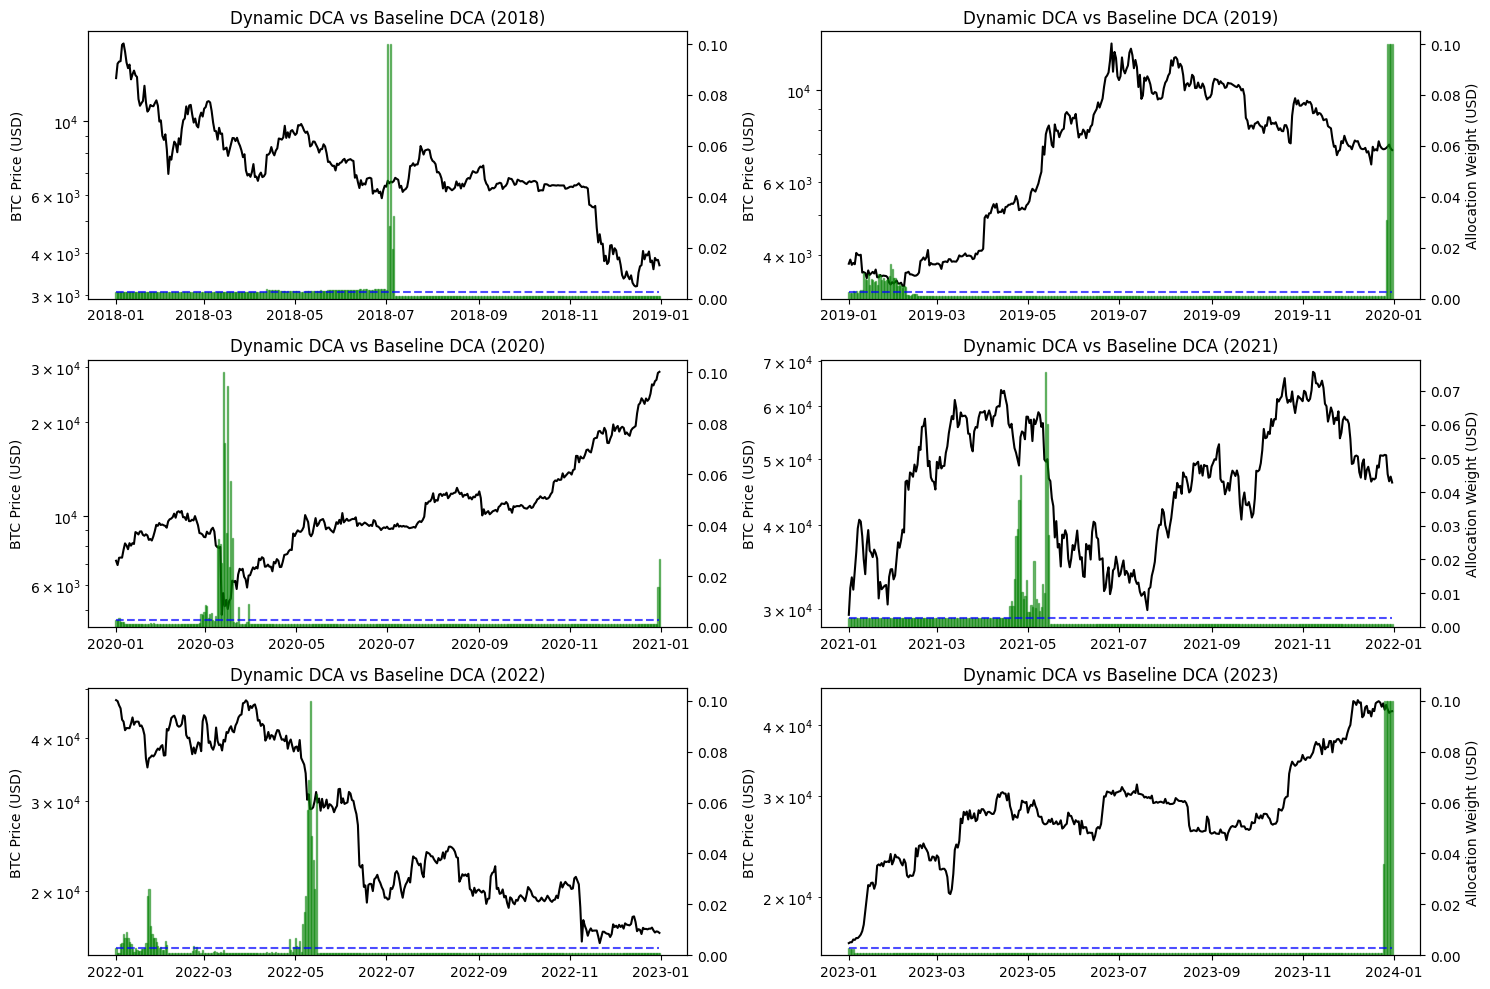

,month,avg_price_usd,avg_sats_per_dollar,total_dynamic_weight,total_baseline_weight,sats_accum_dynamic,sats_accum_baseline
0,2018-01,$12914.87,"7,929",0.0849,0.0849,673,673
1,2018-02,$9392.94,"10,808",0.0767,0.0767,829,829
2,2018-03,$8992.88,"11,335",0.0849,0.0849,962,962
3,2018-04,$8021.25,"12,653",0.0907,0.0822,"1,142","1,040"
4,2018-05,$8421.53,"11,985",0.0960,0.0849,"1,158","1,017"
...,...,...,...,...,...,...,...
67,2023-08,$27862.18,"3,600",0.0310,0.0849,111,305
68,2023-09,$26302.92,"3,803",0.0300,0.0822,114,312
69,2023-10,$29736.01,"3,393",0.0310,0.0849,105,288
70,2023-11,$36586.64,"2,735",0.0300,0.0822,82,224


In [29]:
years = list(range(2018, 2024))
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes = axes.flatten()
for i, year in enumerate(years):
    ax1 = axes[i]
    
    year_data = merged_new.filter(pl.col('date').dt.year() == year).to_pandas()
    if len(year_data) == 0:
        continue
        
    ax1.plot(year_data['date'], year_data['price_usd'], color='black', label='BTC Price')
    ax1.set_ylabel('BTC Price (USD)', color='black')
    ax1.set_yscale('log')
    
    ax2 = ax1.twinx()
    ax2.bar(year_data['date'], year_data['dynamic_weight'], color='green', alpha=0.5, edgecolor='green', linewidth=1, label='Dynamic Weight')
    ax2.plot(year_data['date'], year_data['baseline_weight'], color='blue', alpha=0.7, linestyle='--', label='Baseline')
    
    if i % 2 != 0:
        ax2.set_ylabel('Allocation Weight (USD)')
        
    ax1.set_title(f"Dynamic DCA vs Baseline DCA ({year})")
# Hide the last empty subplot (since we have 13 years and 14 slots)

fig.tight_layout()
plt.show()
# ----------------------------------------------------
# MONTHLY SUMMARY TABLE (Across all years)
# ----------------------------------------------------
monthly = merged_new.with_columns(
    pl.col('date').dt.truncate('1mo').alias('month')
).group_by('month').agg([
    pl.col('price_usd').mean().alias('avg_price_usd'),
    pl.col('sats_per_dollar').mean().alias('avg_sats_per_dollar'), 
    pl.col('dynamic_weight').sum().alias('total_dynamic_weight'),
    pl.col('baseline_weight').sum().alias('total_baseline_weight'),
    pl.col('sats_accumulated_dynamic').sum().alias('sats_accum_dynamic'),
    pl.col('sats_accumulated_baseline').sum().alias('sats_accum_baseline')
]).sort('month')
monthly_pd = monthly.to_pandas()
# Format the columns
monthly_pd['month'] = monthly_pd['month'].dt.strftime('%Y-%m')
monthly_pd['avg_price_usd'] = monthly_pd['avg_price_usd'].round(2).apply(lambda x: f"${x}")
monthly_pd['avg_sats_per_dollar'] = monthly_pd['avg_sats_per_dollar'].apply(lambda x: f"{int(x):,}")
for col in ['total_dynamic_weight', 'total_baseline_weight']:
    monthly_pd[col] = monthly_pd[col].round(4)
for col in ['sats_accum_dynamic', 'sats_accum_baseline']:
    monthly_pd[col] = monthly_pd[col].apply(lambda x: f"{int(x):,}")
# Output table
monthly_pd

# min buy vs total sats

Running threshold sensitivity test... (This will take a minute or two)
Testing threshold: 0.00001...
Testing threshold: 0.00023...
Testing threshold: 0.00045...
Testing threshold: 0.00067...
Testing threshold: 0.00089...
Testing threshold: 0.00112...
Testing threshold: 0.00134...
Testing threshold: 0.00156...
Testing threshold: 0.00178...
Testing threshold: 0.00200...


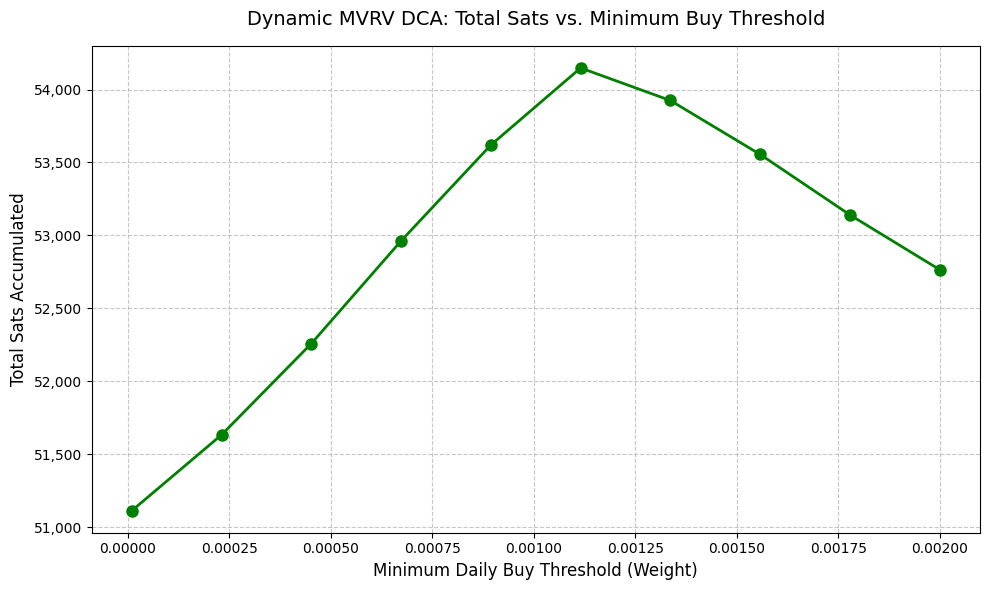

Min Buy: 0.00001 -> 51,114 Sats
Min Buy: 0.00023 -> 51,634 Sats
Min Buy: 0.00045 -> 52,259 Sats
Min Buy: 0.00067 -> 52,963 Sats
Min Buy: 0.00089 -> 53,620 Sats
Min Buy: 0.00112 -> 54,148 Sats
Min Buy: 0.00134 -> 53,925 Sats
Min Buy: 0.00156 -> 53,555 Sats
Min Buy: 0.00178 -> 53,141 Sats
Min Buy: 0.00200 -> 52,765 Sats


In [31]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the core modules to patch
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy
import stacksats.model_development.public
from stacksats import StrategyRunner, ExportConfig, MVRVStrategy

# Load data
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))
runner = StrategyRunner()

# Define test thresholds from 0.00001 to 0.001
test_thresholds = np.linspace(0.00001, 0.002, num=10)
sats_results = []

print("Running threshold sensitivity test... (This will take a minute or two)")

for min_val in test_thresholds:
    print(f"Testing threshold: {min_val:.5f}...")
    
    # 1. Apply the monkey patch for this specific loop
    stacksats.framework_contract.MIN_DAILY_WEIGHT = min_val
    stacksats.runner.validation.MIN_DAILY_WEIGHT = min_val
    stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = min_val
    stacksats.model_development.public.MIN_DAILY_WEIGHT = min_val
    stacksats.model_development.public.MIN_W = min_val
    
    all_dynamic = []
    
    # 2. Run the strategy for all years
    for year in range(2018, 2024):
        config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
        dyn = runner.export(MVRVStrategy(), config, btc_df=btc_df).to_dataframe()
        
        # Flatten Leap Years
        dyn_flat = dyn.group_by('date').agg([
            pl.col('weight').mean().alias('dynamic_weight'),
            pl.col('price_usd').first()
        ])
        all_dynamic.append(dyn_flat)
        
    # 3. Calculate total sats for this specific threshold
    dynamic_weights = pl.concat(all_dynamic)
    dynamic_weights = dynamic_weights.with_columns(
        ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated')
    )
    
    total_sats = dynamic_weights['sats_accumulated'].sum()
    sats_results.append(total_sats)

# ----------------------------------------------------
# PLOT THE RESULTS
# ----------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(test_thresholds, sats_results, marker='o', color='green', linewidth=2, markersize=8)

plt.title('Dynamic MVRV DCA: Total Sats vs. Minimum Buy Threshold', fontsize=14, pad=15)
plt.xlabel('Minimum Daily Buy Threshold (Weight)', fontsize=12)
plt.ylabel('Total Sats Accumulated', fontsize=12)

# Format the Y-axis with commas for readability
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the final raw numbers
for threshold, sats in zip(test_thresholds, sats_results):
    print(f"Min Buy: {threshold:.5f} -> {sats:,.0f} Sats")
